In [1]:
from ase.io import Trajectory
from ase.visualize import view
import os
import numpy as np


In [ ]:
directory = "RANDOM_DISPLACEMENT_RELAXATIONS"
filenames = os.listdir(directory)

strain = str(0.2275)
selected = [f for f in filenames if f.startswith(strain)]

trajfiles = [os.path.join(directory, f) for f in selected]
traj = Trajectory(trajfiles[-1])

In [3]:
view(traj, viewer = "ngl")

In [5]:
global_energies = []
global_forces = []
global_norms = []

for trajfile in trajfiles:

    traj = Trajectory(trajfile)

    forces = [a.get_forces() for a in traj]
    forces = np.array(forces)
    norms = np.linalg.norm(forces, axis = (1, 2))

    energies = [a.get_potential_energy() for a in traj]
    energies = np.array(energies)

    global_energies.append(energies)
    global_forces.append(forces)
    global_norms.append(norms)

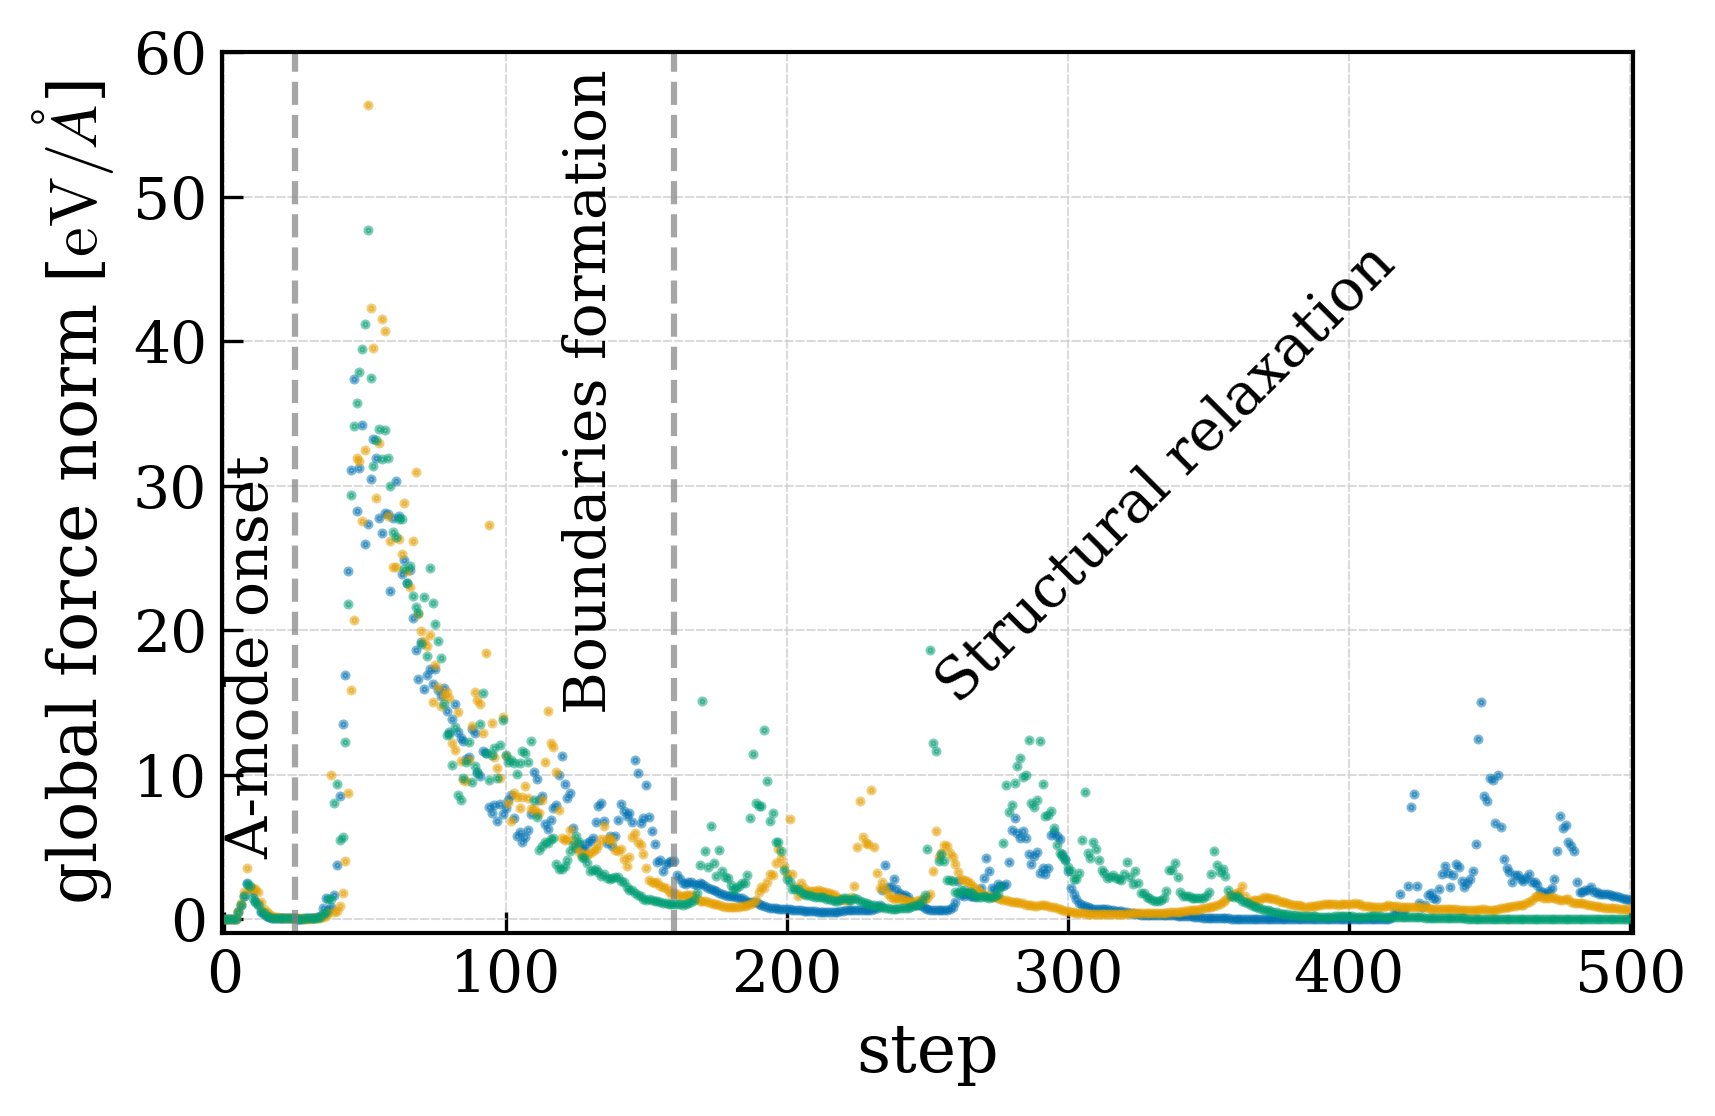

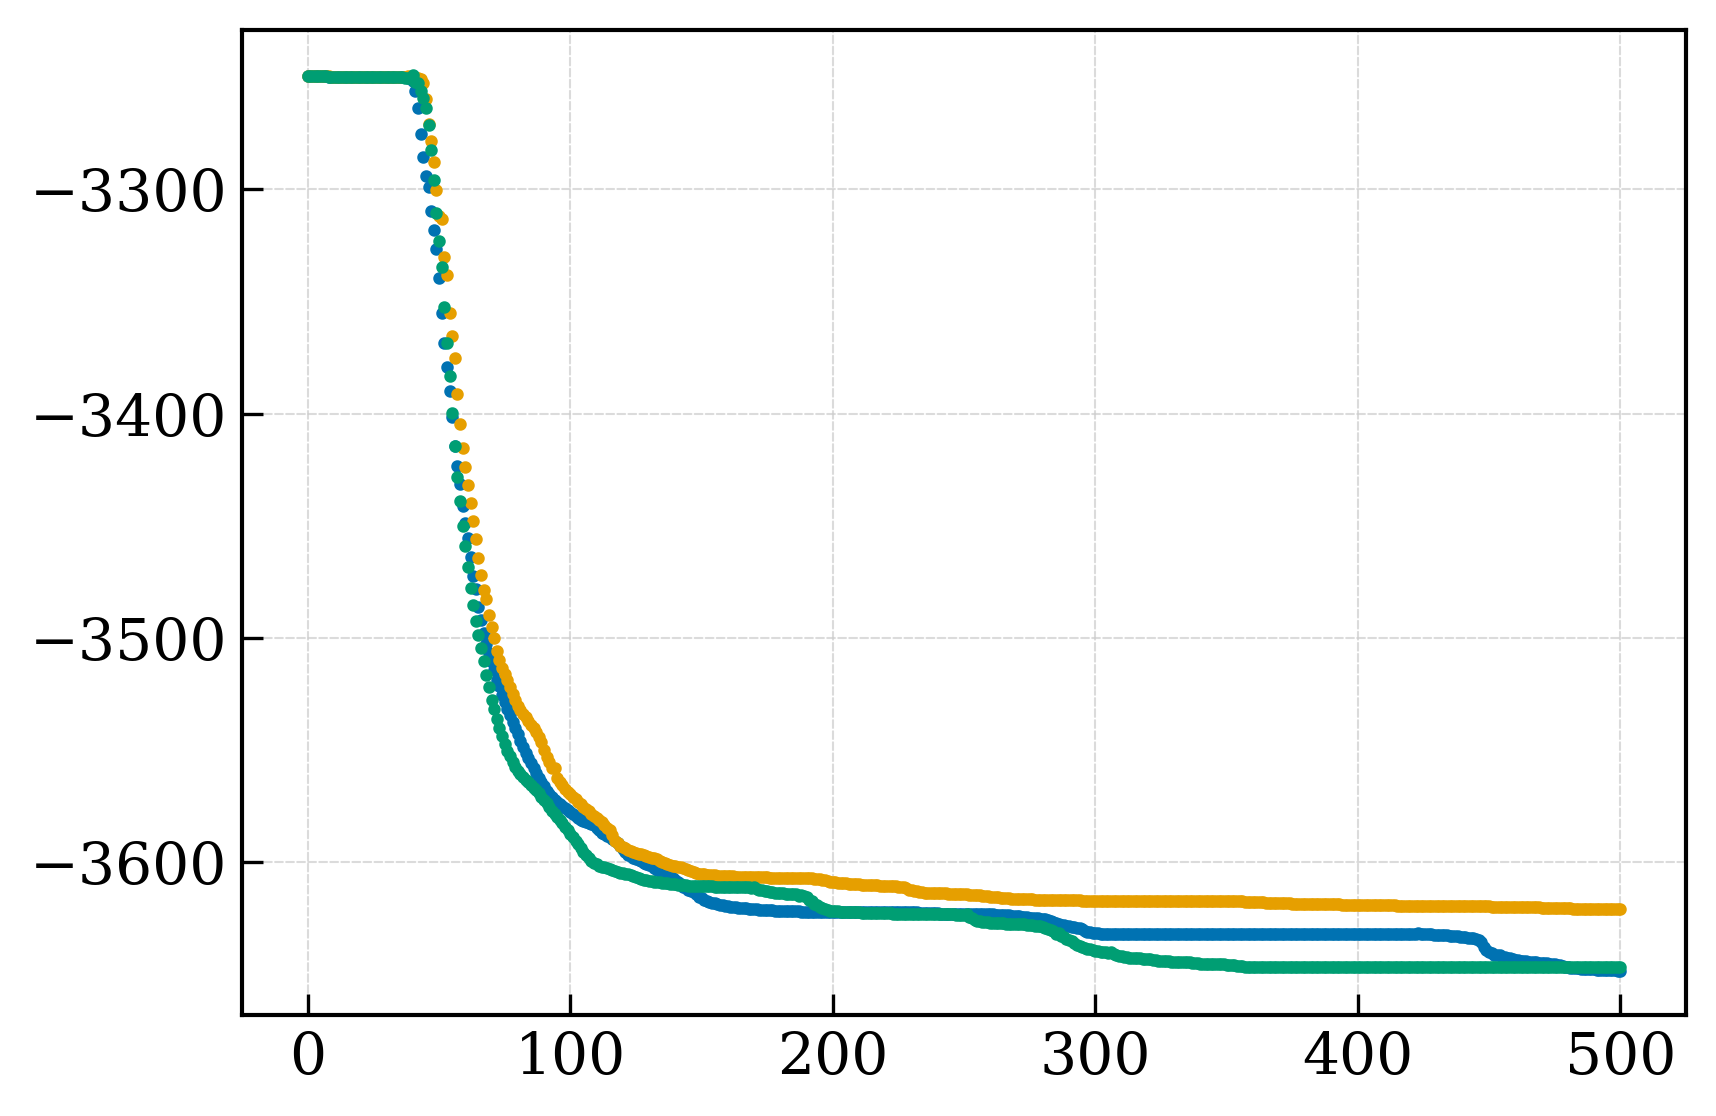

In [11]:
import matplotlib.pyplot as plt

for i in range(len(global_norms)):
    steps = np.arange(0, len(global_norms[i]))
    plt.scatter(steps, global_norms[i], alpha = 0.5, s = 2)

plt.xlabel("step")
plt.ylabel(r"global force norm [$\text{eV}/\AA$]")
plt.vlines([25, 160], -1, 60, linestyle = "--", color = "grey", alpha = 0.7)
plt.annotate("A-mode onset", (0,5), rotation = 90, fontsize = 14)
plt.annotate("Boundaries formation",(120,15), rotation = 90, fontsize = 14)
plt.annotate("Structural relaxation",(250,15), rotation = 45, fontsize = 14)

plt.ylim(-1, 60)
plt.xlim(-1, 501)
plt.tight_layout()
plt.savefig("AmodeRelaxationForces.pdf")
plt.show()
plt.close()

for i in range(len(global_norms)):
    steps = np.arange(0, len(global_energies[i]))
    plt.scatter(steps, global_energies[i])
plt.show()
plt.close()

: 

: 